In [27]:
import numpy as np
from sklearn.datasets import make_blobs, make_moons, make_circles
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

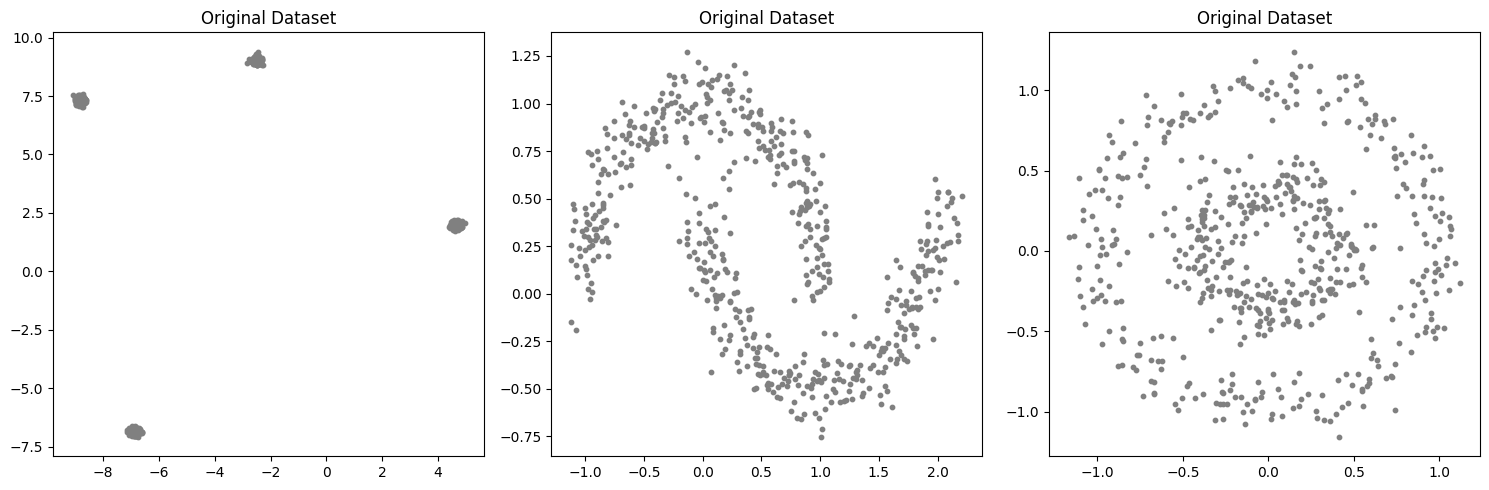

In [28]:
#Blob
X_blobs, y_blobs = make_blobs(n_samples=600, centers=4, cluster_std=0.10, random_state=42)
#Moon
X_moons, y_moons = make_moons(n_samples=600, noise=0.10 , random_state=42 )
#Circle
X_circles, y_circles = make_circles(n_samples=600, factor=0.4, noise=0.10, random_state=42)

datasets ={
    "Blobs": X_blobs,
    "Moons": X_moons,
    "Circles": X_circles
}
fig, axes = plt.subplots(1,3, figsize=(15,5))
for ax, (name, data) in zip(axes, datasets.items()):
    ax.scatter(data[:,0], data[:,1], s=10, c='gray')
    ax.set_title(f"Original Dataset")
plt.tight_layout()
plt.show()


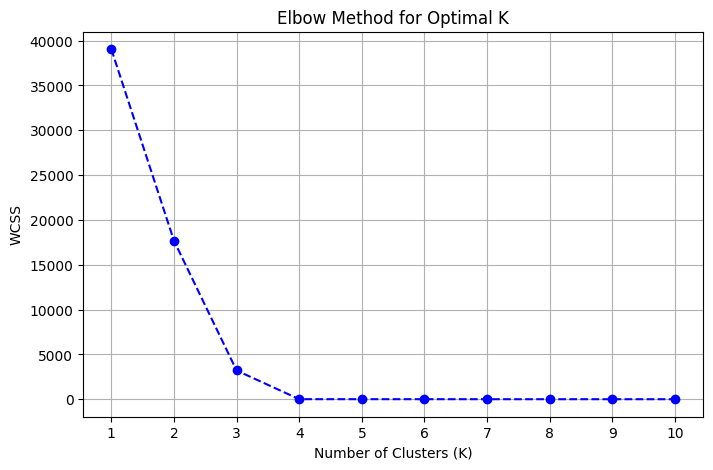

In [29]:
#Elbow Method for Blobs
wcss = []
k_values = range(1,11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_blobs)
    wcss.append(kmeans.inertia_)
#Plot Wcss against the number of clusters
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(k_values)
plt.grid(True)
plt.show()

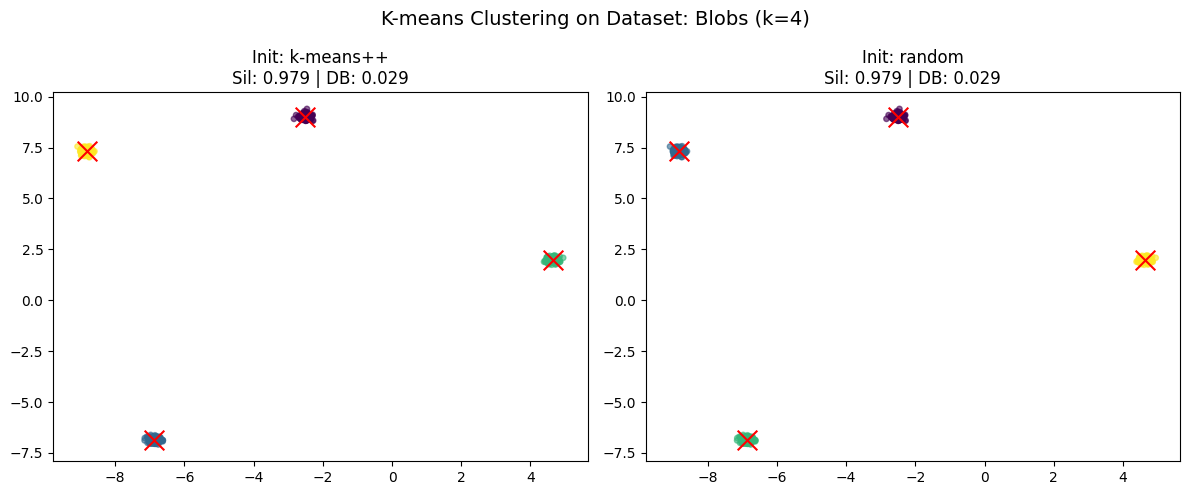

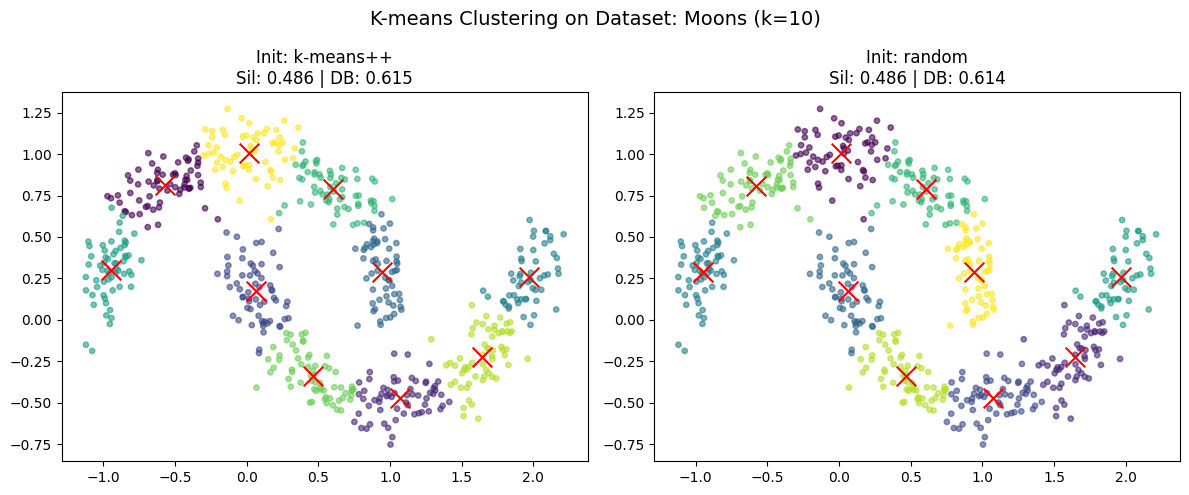

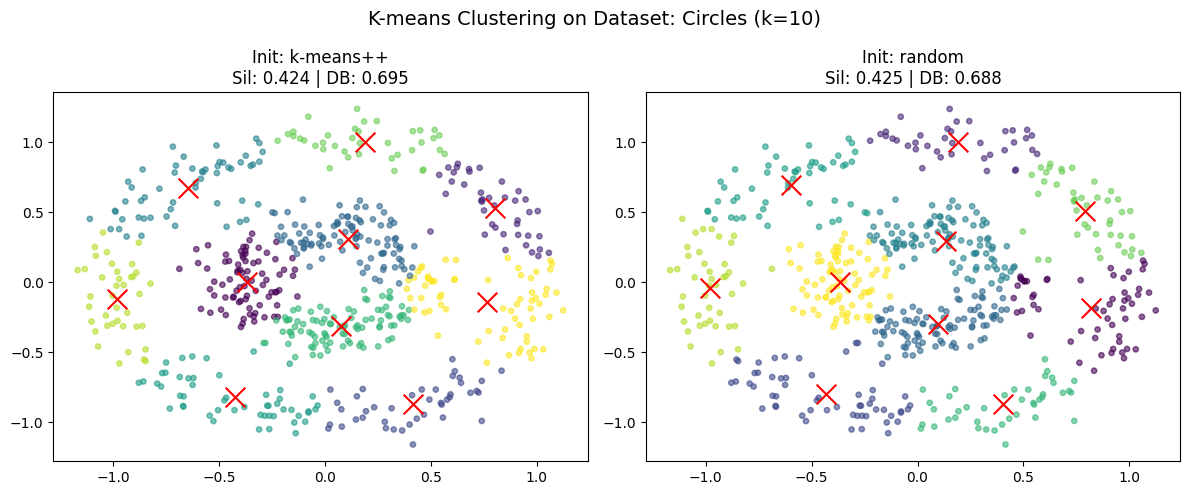

Metrics Summary:
Dataset: Blobs, Init Method: k-means++
Silhouette Score: 0.9792
Davies-Bouldin Score: 0.0294
Calinski-Harabasz Score: 666814.4559

Dataset: Blobs, Init Method: random
Silhouette Score: 0.9792
Davies-Bouldin Score: 0.0294
Calinski-Harabasz Score: 666814.4559

Dataset: Moons, Init Method: k-means++
Silhouette Score: 0.4858
Davies-Bouldin Score: 0.6147
Calinski-Harabasz Score: 1487.4392

Dataset: Moons, Init Method: random
Silhouette Score: 0.4863
Davies-Bouldin Score: 0.6141
Calinski-Harabasz Score: 1487.2748

Dataset: Circles, Init Method: k-means++
Silhouette Score: 0.4237
Davies-Bouldin Score: 0.6948
Calinski-Harabasz Score: 532.5453

Dataset: Circles, Init Method: random
Silhouette Score: 0.4245
Davies-Bouldin Score: 0.6882
Calinski-Harabasz Score: 535.8842



In [35]:


#K-means implementation and evalutation
init_methods = ['k-means++', 'random']
optimal_k_blobs = 4
k_dict = {"Blobs": optimal_k_blobs, "Moons": 10, "Circles": 10}

metrics_results = []

for name, X in datasets.items():
    k = k_dict[name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'K-means Clustering on Dataset: {name} (k={k})', fontsize=14)

    for i, init_method in enumerate(init_methods):
        kmeans = KMeans(n_clusters=k, init=init_method, n_init=10, random_state=42)
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_

        sil_score = silhouette_score(X, labels)
        db_score = davies_bouldin_score(X, labels)
        ch_score = calinski_harabasz_score(X, labels)

        metrics_results.append({
            "Dataset": name,
            "Init Method": init_method,
            "Silhouette Score": sil_score,
            "Davies-Bouldin Score": db_score,
            "Calinski-Harabasz Score": ch_score
        })

        axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=15, alpha=0.6)

        axes[i].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, label='Centroids')
        axes[i].set_title(f"Init: {init_method}\nSil: {sil_score:.3f} | DB: {db_score:.3f}")

    plt.tight_layout()
    plt.show()

# Print metrics summary once after processing all datasets
print(f"Metrics Summary:")
for res in metrics_results:
    print(f"Dataset: {res['Dataset']}, Init Method: {res['Init Method']}")
    print(f"Silhouette Score: {res['Silhouette Score']:.4f}")
    print(f"Davies-Bouldin Score: {res['Davies-Bouldin Score']:.4f}")
    print(f"Calinski-Harabasz Score: {res['Calinski-Harabasz Score']:.4f}\n")

# **Lab Report**
# **Introduction**
After running KMeans on all three datasets (blobs, moons, and circles), it became clear that this algorithm has a strong preference for a particular type of data structure, and it struggles significantly when that structure is absent. The blobs dataset produced near-perfect results, while the moons and circles datasets exposed fundamental limitations in how KMeans defines and identifies clusters. This report breaks down the results, explains the geometric reasoning behind KMeans's behavior, and connects the performance metrics to the visual outputs.
#**The Geometric Assumptions Behind KMeans**
Understanding why the results varied so dramatically requires looking at what KMeans is actually optimizing. The algorithm assigns each data point to the nearest centroid using Euclidean distance, recalculates each centroid as the mean of its assigned points, and iterates until convergence. This process minimizes within-cluster sum of squares (WCSS), which is essentially a measure of how tightly packed each cluster is around its center.
The critical implication of using Euclidean distance as the assignment criterion is that KMeans implicitly assumes clusters exhibit isotropic (spherical) variance. In other words, the algorithm expects data to spread out roughly equally in all directions from the centroid, forming compact, convex, blob-like regions. Every decision boundary KMeans draws is a perpendicular bisector between two centroids, which means the resulting partitions are always Voronoi cells. These cells are convex polygons by definition, so KMeans is structurally incapable of representing a cluster that bends, curves, or wraps around another cluster.
This is not a tuning issue or an initialization problem. It is a hard constraint built into the algorithm's objective function. When the true clusters happen to be roughly spherical and well-separated, this assumption is harmless. When they are not, no amount of restarts or careful initialization will fix the mismatch.
# **Performance on the Blobs Dataset**
The blobs dataset was generated with four centers and a very low cluster standard deviation (0.10), producing four tight, well-separated, roughly spherical groups. This is the ideal scenario for KMeans because the data's actual geometry aligns perfectly with the algorithm's assumptions.
The metrics confirmed this. The Silhouette Score was 0.9792 for both k-means++ and random initialization, indicating that nearly every point was far closer to its own centroid than to any neighboring one. The Davies-Bouldin Score was 0.0294, reflecting extremely compact clusters with large inter-cluster separation. The Calinski-Harabasz Score reached 666,814, showing an enormous ratio of between-cluster to within-cluster dispersion.
In the visualizations, the cluster assignments were visually indistinguishable from the ground truth labels. Each centroid landed squarely in the center of its respective blob, and the decision boundaries fell cleanly in the empty space between groups. There was essentially no misclassification because the data presented no ambiguity under the Euclidean distance framework.
# **Failure on the Moons Dataset**
The moons dataset consists of two interleaving crescent-shaped clusters. Each crescent curves around the other, creating a structure that is visually obvious to a human observer but fundamentally non-convex. No single point can serve as a meaningful "center" for a crescent, and no straight-line boundary can separate the two groups.
KMeans, constrained to its Voronoi partitioning logic, placed centroids in the approximate center of mass of each half of the data and drew a linear boundary between them. The result, visible in the clustering plots, was that the algorithm sliced through both crescents rather than separating them. Points from both moons ended up mixed together in each cluster.
The Silhouette Score dropped to approximately 0.486, a decline of more than 50% from the blobs result. A Silhouette Score in this range indicates that a substantial number of points are roughly equidistant between their assigned cluster and the nearest alternative, meaning the cluster assignments are weakly defined. The Davies-Bouldin Score increased to 0.615, and the Calinski-Harabasz Score fell to around 1,487.
Notably, both initialization methods produced nearly identical metrics, which rules out initialization sensitivity as an explanation. The poor performance is not a convergence issue; it is a modeling issue. KMeans converged to the optimal solution given its objective function, but that objective function cannot represent the true cluster structure.
# **Failure on the Circles Dataset**
The circles dataset contains two concentric rings: a smaller circle nested inside a larger one. This geometry is arguably even more adversarial for KMeans than the moons, because the inner cluster is entirely surrounded by the outer cluster in every direction. There is no hyperplane or Voronoi boundary that can isolate a ring from the circle enclosing it.
As expected, KMeans partitioned the data by cutting through both rings, typically dividing the space into left and right halves (or some similar linear split). The visualizations showed points from both the inner and outer rings assigned to every cluster, with no meaningful separation of the actual groups.
The Silhouette Score fell further to approximately 0.424, the lowest across all three datasets. The Davies-Bouldin Score rose to about 0.695, and the Calinski-Harabasz Score dropped to roughly 533. The continued degradation across all three metrics, relative to both the blobs and the moons, confirms that concentricity represents an even greater mismatch with KMeans's spherical assumptions than the crescent shapes did.
# **Comparing the Metrics Across Datasets**
Placing the performance numbers side by side makes the pattern undeniable. The Silhouette Score progressed from 0.979 (blobs) to 0.486 (moons) to 0.424 (circles). The Davies-Bouldin Score roughly doubled from blobs to the non-convex datasets. The Calinski-Harabasz Score dropped from nearly 667,000 on blobs to about 1,500 on moons and 530 on circles, a decline spanning several orders of magnitude.
The blobs metrics indicate clustering that is essentially perfect: tight, well-separated groups with almost no overlap. The moons and circles metrics, by contrast, indicate clustering that is barely better than arbitrary. The gap between these results is not incremental. It reflects a qualitative difference between a dataset that matches the algorithm's assumptions and datasets that violate them entirely.
# **Conclusion**
KMeans is not a general-purpose clustering solution. It is a highly effective algorithm for a specific class of problems data that naturally forms compact, convex, roughly spherical groups with clear separation. The blobs dataset fit this description almost perfectly, and the results were correspondingly strong.
The moons and circles datasets demonstrated what happens when the assumption of isotropic variance breaks down. KMeans still ran, still converged, and still returned cluster labels without any warning. But the labels were wrong in ways that were immediately visible in the plots, and the Silhouette Scores dropped by more than half. The algorithm was not making errors due to noise or insufficient data. It was failing because its internal model of what a cluster looks like does not match the actual geometry of crescents or concentric rings.
For non-convex cluster structures like these, density-based methods such as DBSCAN or connectivity-based approaches like spectral clustering would be far more appropriate, since they do not rely on distance from a central point to define cluster membership.

